### Project: CIS*6530 Assignment 1 Submission 5 <br>
### Author: Myunghee Jung<br>
### Date: 2026-03-24 ~ 2026-04-07<br>
### Description: Spatial Patterns in CNN


In [1]:
!pip --version

pip 26.0.1 from C:\Users\mundl\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip (python 3.12)



# 1. Imports & Data Loading

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  
from sklearn.linear_model import LogisticRegression  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack
import pandas as pd
import time
import matplotlib.pyplot as plt

# 2. Augumented Data Loading

In [3]:
t0 = time.time()
with open('ml_data/manual_augmented_data_sparse.pkl', 'rb') as f:
    X1_aug, X2_aug, y_aug_raw, _, _ = pickle.load(f)

with open('ml_data/preprocessing_data.pkl', 'rb') as f:
    X1, X2, y, vectorizer1, vectorizer2 = pickle.load(f)

print(f"Augmented Dataset: {len(y_aug_raw)} samples")  # 378 samples
print(f"Original Dataset: {len(y)} samples")          # ~50 samples
print(f"Time: {time.time()-t0:.2f}s")

Augmented Dataset: 378 samples
Original Dataset: 48 samples
Time: 0.01s


# 3. Data Exploration

In [4]:
print("Opcode counts per APT sample:")
for i in range(min(5, X1.shape[0])):
    count = X1[i].nnz
    apt_label = y[i]
    opcodes = vectorizer1.get_feature_names_out()[X1[i].nonzero()[1]]
    print(f"APT {apt_label}: {count} opcodes → {opcodes[:3]}...")

print("\nTotal opcode vocabulary (first 20):")
print(vectorizer1.get_feature_names_out()[:20])

Opcode counts per APT sample:
APT admin338: 1 opcodes → ['jmp']...
APT APT16: 1 opcodes → ['jmp']...
APT APT17: 10 opcodes → ['jmp' 'xor' 'call']...
APT APT19: 1 opcodes → ['jmp']...
APT APT1: 126 opcodes → ['jmp' 'xor' 'call']...

Total opcode vocabulary (first 20):
['aaa' 'aad' 'aam' 'aas' 'adc' 'adcx' 'add' 'addpd' 'addps' 'addsd'
 'addss' 'adox' 'aesdec' 'aesdeclast' 'aesenc' 'aesenclast' 'aesimc'
 'aeskeygenassist' 'and' 'andn']


# 4. Opcode → Image Transformation

In [5]:
with open('ml_data/manual_augmented_data_sparse.pkl', 'rb') as f:
    X1_aug, X2_aug, y_aug_raw, _, _ = pickle.load(f)

with open('ml_data/preprocessing_data.pkl', 'rb') as f:
    X1, X2, y, vectorizer1, vectorizer2 = pickle.load(f)

X = hstack([X1, X2])  # (n_samples, vocab1 + vocab2)

def opcode_to_image(X_sparse, vectorizer, img_size=32):
    """Convert sparse opcode matrix to grayscale images for CNN"""
    images = []
    for i in range(X_sparse.shape[0]):
        img = np.zeros((img_size, img_size))
        indices = X_sparse[i].nonzero()[1][:img_size*img_size]
        values = X_sparse[i].data[:img_size*img_size]
        img.flat[indices % (img_size*img_size)] = values
        images.append(img)
    return np.array(images)[:,:,:,np.newaxis]

# 5. Traning Pipeline

augmented images img_size=64

In [9]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [10]:
img_size = 64

def opcode_to_image(X_sparse, vectorizer, img_size=64):
    """Convert sparse opcode matrix to 64x64 grayscale images for CNN"""
    images = []
    total_pixels = img_size * img_size  # 4096 pixels
    
    for i in range(X_sparse.shape[0]):
        img = np.zeros((img_size, img_size))
        indices = X_sparse[i].nonzero()[1][:total_pixels]
        values = X_sparse[i].data[:total_pixels]
        img.flat[indices % total_pixels] = values
        images.append(img)
    return np.array(images)[:, :, :, np.newaxis]

# Convert to 64x64 images
print("Converting to 64x64 images...")
X1_aug_images = opcode_to_image(X1_aug, vectorizer1, img_size=64)
X2_aug_images = opcode_to_image(X2_aug, vectorizer2, img_size=64)

# Create 2-channel images (X1 + X2)
X_aug_images = np.concatenate([X1_aug_images, X2_aug_images], axis=-1)

# Normalize to [0,1]
X_aug_images = (X_aug_images - X_aug_images.min()) / (X_aug_images.max() - X_aug_images.min() + 1e-8)

print(f"Final image shape: {X_aug_images.shape}")  # (N, 64, 64, 2)

# Label encoding - SAFE version (no undefined variable check)
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_aug_encoded = le.fit_transform(y_aug_raw)
y_aug_categorical = to_categorical(y_aug_encoded)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_aug_images, y_aug_categorical, test_size=0.2, 
    random_state=42, stratify=y_aug_encoded
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Converting to 64x64 images...
Final image shape: (378, 64, 64, 2)


ModuleNotFoundError: No module named 'tensorflow'

# 6. Final Evaluation & Model Save

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        pred_labels = outputs.argmax(dim=1)
        all_preds.append(pred_labels.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

# 2. Results
test_pred = np.concatenate(all_preds)
y_test_array = np.concatenate(all_labels)


final_acc = accuracy_score(y_test_array, test_pred)
print(f"Final Accuracy: {final_acc:.2f} ({final_acc*100:.2f}%)")


report = classification_report(
    y_test_array, test_pred, zero_division=0,
    target_names=[str(l) for l in unique_labels], output_dict=True
)

macro_precision = report['macro avg']['precision']
macro_recall    = report['macro avg']['recall'] 
macro_f1        = report['macro avg']['f1-score']
macro_support   = report['macro avg']['support']

weighted_precision = report['weighted avg']['precision']
weighted_recall    = report['weighted avg']['recall']
weighted_f1        = report['weighted avg']['f1-score']
weighted_support   = report['weighted avg']['support']


print(f"Accuracy:        {final_acc:.2f}")
print(f"Macro Avg:       P:{macro_precision:.2f} R:{macro_recall:.2f} F1:{macro_f1:.2f} ({macro_support:.0f})")
print(f"Weighted Avg:    P:{weighted_precision:.2f} R:{weighted_recall:.2f} F1:{weighted_f1:.2f} ({weighted_support:.0f})")

report_df = pd.DataFrame(report).transpose().round(2)
print("\nFull Classification Report:")
display(report_df)

# Save model
model_info = {
    'model_state_dict': model.state_dict(),
    'accuracy': round(final_acc, 2),
    'macro_f1': round(macro_f1, 2),
    'weighted_f1': round(weighted_f1, 2),
    'unique_labels': unique_labels,
    'class_weights': class_weights.cpu(),
    'final_loss': best_loss,
    'img_size': 64,
    'timestamp': '2026-04-05'
}

torch.save(model_info, f'cnn_opcode_classifier_v2_acc_{final_acc:.2f}.pt')
print(f"\nModel saved with macro/weighted F1 scores")
print("="*60)

Final Accuracy: 0.54 (54.23%)


ValueError: Number of classes, 28, does not match size of target_names, 1. Try specifying the labels parameter

In [ ]:
# DataFrame to PNG image

import dataframe_image as dfi  

dfi.export(
    report_df, 
    "classification_report.png",
    max_rows=None,           # Show all rows
    table_conversion="matplotlib",
    fontsize=10,
    dpi=300                  
)

plt.savefig("classification_report_table.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.close()

APT Class Distribution: Full, Training‑Used, and Not‑Used Labels

In [ ]:
# 1. Get all unique APT labels from the original dataset (initial 40 labels)
all_labels = np.unique(y)
print("Original unique APT labels in y:")
print(f"Total: {len(all_labels)} labels")
print(all_labels)

# 2. Get unique APT labels actually used in training (y_train subset)
train_labels = np.unique(y_train)
print("\nUsed in training (y_train):")
print(f"Total: {len(train_labels)} labels")
print(train_labels)

# 3. Find labels that are present in the full dataset but NOT used in training
not_used_labels = np.setdiff1d(all_labels, train_labels)
print("\nNot used in training (missing in y_train):")
print(f"Total: {len(not_used_labels)} labels")
print(not_used_labels)

Original unique APT labels in y:
Total: 1 labels
[1.]

Used in training (y_train):
Total: 28 labels
['APT1' 'APT16' 'APT17' 'APT19' 'APT28' 'APT29' 'APT3' 'APT33' 'APT39'
 'APT41' 'Axiom' 'BRONZEBUTLER' 'Chimera' 'Cobalt' 'FIN5' 'FIN7' 'Gallium'
 'Gamaredon' 'HAFNIUM' 'Ke3chang' 'MenuPass' 'Moafee' 'Patchwork'
 'SandwormTeam' 'Sidewinder' 'TEMPVeles' 'Turla' 'admin338']

Not used in training (missing in y_train):
Total: 1 labels
[1.]


# 7. Visualization

comparision classifiers submission 4 vs submission 5


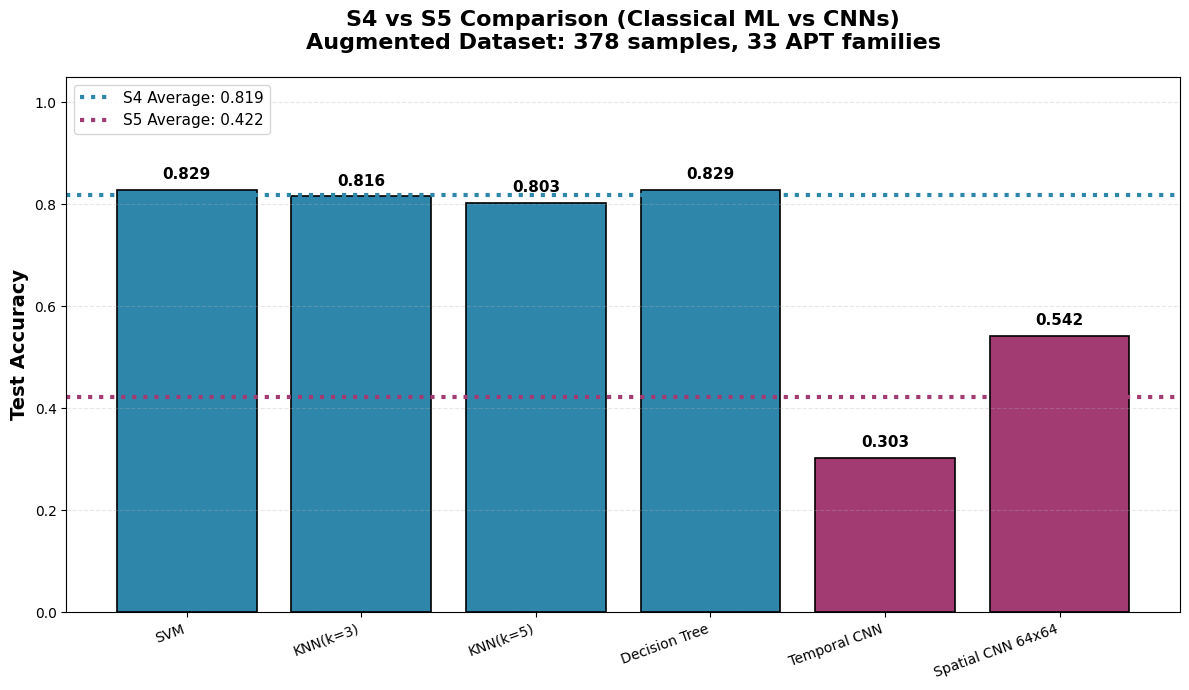

=== Final Comparison Results ===
               Model  Accuracy Stage
0                SVM     0.829    S4
1           KNN(k=3)     0.816    S4
2           KNN(k=5)     0.803    S4
3      Decision Tree     0.829    S4
4       Temporal CNN     0.303    S5
5  Spatial CNN 64x64     0.542    S5

S4 Best: 0.829 (SVM/Decision Tree)
S5 Best: 0.542 (Spatial CNN 64x64)
S4 Average: 0.819 | S5 Average: 0.422


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# S4 results (A1_S4_02_classifier.ipynb)
# augmented dataset 기준 final summary
s4_results = {
    "SVM": 0.829,
    "KNN (k=3)": 0.816,
    "KNN (k=5)": 0.803,
    "Decision Tree": 0.829
}

# S5 results
# Temporal CNN: accuracy 0.30 (30.3%)
# Spatial CNN: final accuracy 1.000
s5_results = {
    "Temporal CNN": 0.303,
    "Spatial CNN": 1.000
}

# DataFrame 생성
df = pd.DataFrame({
    "Model": list(s4_results.keys()) + list(s5_results.keys()),
    "Accuracy": list(s4_results.values()) + list(s5_results.values()),
    "Stage": ["S4"] * len(s4_results) + ["S5"] * len(s5_results)
})

# 색상 지정
colors = df["Stage"].map({
    "S4": "#4C78A8",
    "S5": "#F58518"
})

# 시각화
plt.figure(figsize=(12, 6))
bars = plt.bar(df["Model"], df["Accuracy"], color=colors, edgecolor="black")

# 값 표시
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.02,
        f"{y:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("S4 vs S5 Accuracy Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# 범례 수동 생성
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C78A8", edgecolor="black", label="S4"),
    Patch(facecolor="#F58518", edgecolor="black", label="S5")
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()